In [19]:
import os
import matplotlib.pyplot as plt
from glob import glob as gg
from collections import Counter
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, max, min
from tensorflow.keras.models import Model
from pyspark.sql.types import StringType, ArrayType, IntegerType, FloatType

In [2]:
spark = SparkSession.builder \
            .appName("LSTMJsonExtractor") \
            .config("spark.driver.port", "5432") \
            .config("spark.blockManager.port", "4321") \
            .config("spark.driver.memory", "8g") \
            .config("spark.executor.memory", "8g") \
            .config("spark.driver.maxResultSize", "8g") \
            .getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/04/20 03:04:18 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
images_dir = "archive/batch_*/background_images/*.jpg"

image_paths = gg(f"{images_dir}")

json_dir = "archive/batch_*/json/*"

json_paths = gg(f"{json_dir}")

lookup_dict = {os.path.basename(path): path for path in image_paths}

broadcast_lookup = spark.sparkContext.broadcast(lookup_dict)

In [6]:
def locate_image_path(row):
    
    image_filename = row.asDict().get("filename", None)

    if image_filename:
        return broadcast_lookup.value.get(image_filename, None)
    return None

def process_lstm_input(row):
    lstm_input = []
    row_dict = row.asDict()
    image_path = locate_image_path(row)
    if image_path:
        lstm_input.append([
                        image_path, 
                        row_dict["full_latex_chars"], 
                        row_dict["visible_latex_chars"], 
                        len(row_dict["visible_latex_chars"]), 
                    ])
        
def ctc_lambda_func(args):
    y_pred, labels, input_length, label_length = args
    return K.ctc_batch_cost(labels, y_pred, input_length, label_length)

In [4]:
images_df = spark.createDataFrame([], schema = spark.read.json(json_paths[0]).schema)

for path in json_paths:
    temp_df = spark.read.json(path)
    images_df = images_df.union(temp_df)

images_exp = images_df.withColumn("filename", col("filename").cast(StringType())). \
                        withColumn("latex", col("latex").cast(StringType())). \
                        withColumn("full_latex_chars", col("image_data.full_latex_chars").cast(StringType())). \
                        withColumn("visible_latex_chars", col("image_data.visible_latex_chars").cast(ArrayType(StringType()))). \
                        withColumn("visible_char_map", col("image_data.visible_char_map").cast(StringType())). \
                        withColumn("width", col("image_data.width").cast(FloatType())). \
                        withColumn("height", col("image_data.height").cast(FloatType())). \
                        withColumn("depth", col("image_data.depth").cast(FloatType())). \
                        withColumn("xmins", col("image_data.xmins").cast(ArrayType(FloatType()))). \
                        withColumn("xmaxs", col("image_data.xmaxs").cast(ArrayType(FloatType()))). \
                        withColumn("ymins", col("image_data.ymins").cast(ArrayType(FloatType()))). \
                        withColumn("ymaxs", col("image_data.ymaxs").cast(ArrayType(FloatType()))). \
                        withColumn("xmins_raw", col("image_data.xmins_raw").cast(ArrayType(IntegerType()))). \
                        withColumn("xmaxs_raw", col("image_data.xmaxs_raw").cast(ArrayType(IntegerType()))). \
                        withColumn("ymins_raw", col("image_data.ymins_raw").cast(ArrayType(IntegerType()))). \
                        withColumn("ymaxs_raw", col("image_data.ymaxs_raw").cast(ArrayType(IntegerType()))). \
                        withColumn("png_masks", col("image_data.png_masks").cast(ArrayType(StringType())))

images_red = images_exp.drop("font", "image_data", "unicode_less_curlies", "unicode_str", "uuid", "visible_char_map")


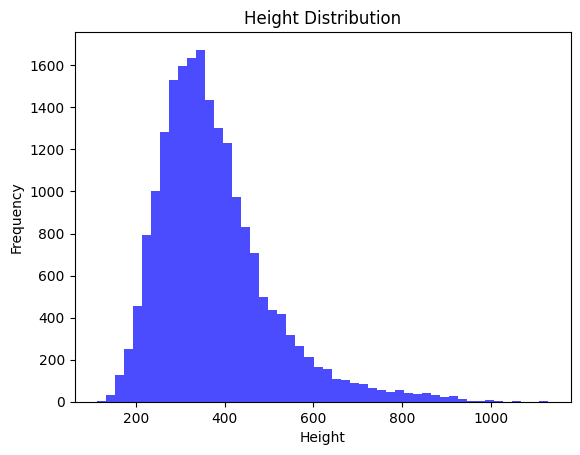

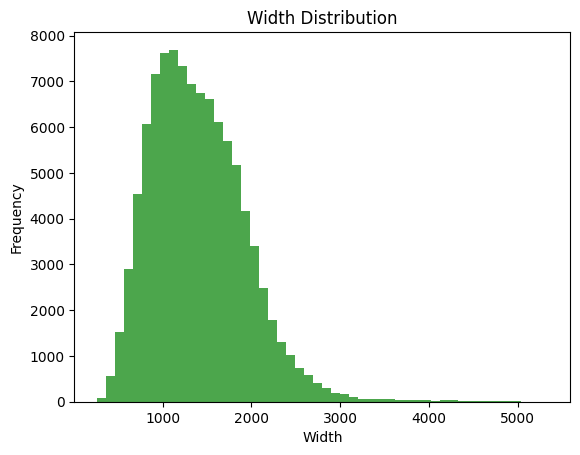

In [6]:
# Exploration of the DataFrame

# Height distribution
sample_fraction = 0.2
heights = images_exp.select("height") \
                  .sample(fraction=sample_fraction, seed=42) \
                  .toPandas()["height"]
plt.hist(heights, bins = 50, color = 'gray', alpha = 0.7)
plt.title("Height Distribution")
plt.xlabel("Height")
plt.ylabel("Frequency")
plt.show()

# Width distribution
widths = images_exp.select("width").rdd.flatMap(lambda x: x).collect()
plt.hist(widths, bins = 50, color = 'gray', alpha = 0.7)
plt.title("Width Distribution")
plt.xlabel("Width")
plt.ylabel("Frequency")
plt.show()

In [10]:
# Depth distribution
# depths = images_exp.select("depth").rdd.flatMap(lambda x: x).collect()
# plt.hist(depths, bins=50, color='red', alpha=0.7)
# plt.title("Depth Distribution")
# plt.xlabel("Depth")
# plt.ylabel("Frequency")
# plt.show()

# Bar chart of visible latex chars count
# visible_latex_chars_counts = images_exp.select("visible_latex_chars").rdd.map(lambda x: len(x[0]) if x[0] else 0).collect()
# plt.bar(range(len(visible_latex_chars_counts)), visible_latex_chars_counts, color='purple', alpha=0.7)

visible_latex = images_exp.select("visible_latex_chars").sample(fraction = 0.001, seed = 42).toPandas()

all_chars = [
    token
    for arr in visible_latex["visible_latex_chars"]
    for token in arr
]

# all_chars.append(visible_latex.map(lambda x: x[::]))
all_chars[:5]
# plt.title("Visible Latex Chars Count")
# plt.xlabel("Index")
# plt.ylabel("Count")
# plt.show()

['\\lim_', 'k', '\\to', '0', '-']

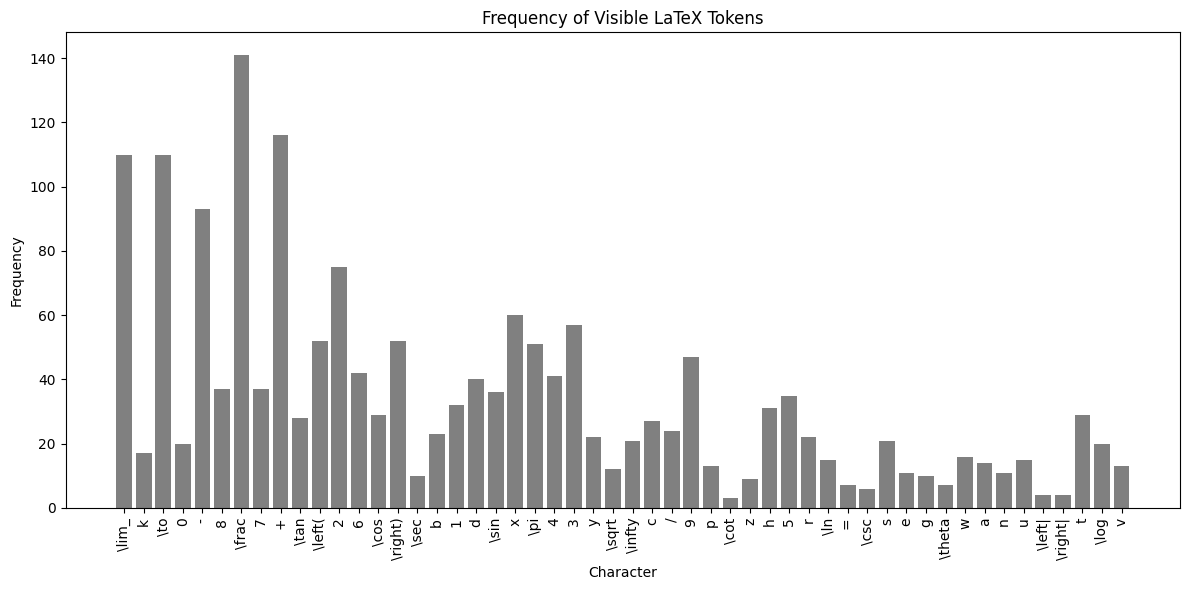

In [25]:

char_count = Counter(all_chars)

chars = list(char_count.keys())
counts = list(char_count.values())

plt.figure(figsize = (12, 6))
plt.bar(chars, counts, color = "gray")
plt.xticks(rotation = 90)
plt.xlabel("Character")
plt.ylabel("Frequency")
plt.title("Frequency of Visible LaTeX Tokens")
plt.tight_layout()
plt.show()

In [ ]:
all_labels_df = images_exp.select("full_latex_chars").sample(fraction = 0.01, seed = 42).toPandas()

all_labels = [
    token
    for arr in all_labels_df["full_latex_chars"]
    for token in arr
]

label_count = Counter(all_labels)

lab_keys = label_count.keys()
lab_vals = label_count.values()

plt.figure(figsize = (15, 6))
plt.bar(lab_keys, lab_vals, color = "gray")
plt.xticks(rotation = 90)
plt.show()

In [6]:
max_width = images_red.agg(max("width")).collect()[0][0]
min_width = images_red.agg(min("width")).collect()[0][0]
max_height = images_red.agg(max("height")).collect()[0][0]
min_height = images_red.agg(min("height")).collect()[0][0]
print(f"Max height: {max_height} \nMin height: {min_height} \nMax width: {max_width} \nMin width: {min_width}")

Max height: 1197.0 
Min height: 100.0 
Max width: 5340.0 
Min width: 259.0


In [7]:
# 1197.0 100.0 5340.0 259.0

In [8]:
images_small_dims = images_red.filter((col("width") <= 1000) & (col("height") <= 300))

In [9]:
images_small_dims.select("width", "height").show(5)
print(images_small_dims.count())

+-----+------+
|width|height|
+-----+------+
|941.0| 265.0|
|982.0| 290.0|
|894.0| 233.0|
|976.0| 202.0|
|803.0| 205.0|
+-----+------+
only showing top 5 rows



13861


In [10]:
# feature_model = load_model('models/symbol_model.keras')

In [11]:
# normalizing image inputs to the model

In [12]:
images_small_dims.coalesce(1).write.parquet("data/images_small_dims.parquet")
# images_small_dims.coalesce(1).write.format("parquet").save("data/images_small_dims.parquet")

In [13]:
temp = spark.read.parquet("data/images_small_dims.parquet")

temp.show(5)

+--------------------+--------------------+--------------------+-----+------+-----+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|            filename|               latex| visible_latex_chars|width|height|depth|               xmins|               xmaxs|               ymins|               ymaxs|           xmins_raw|           xmaxs_raw|           ymins_raw|           ymaxs_raw|           png_masks|
+--------------------+--------------------+--------------------+-----+------+-----+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|436008a6-638f-4bd...|\lim_{x\to1^{+}}-...|[\lim_, x, \to, 1...|941.0| 265.0|  4.0|[0.023404256, 0.0...|[0.25851065, 0.08...|[0.053030305, 0.8...|[0.594697, 0.9810...|[22, 55, 91, 1